In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("D:/Data Analyst/project/Python_Netflix_Content_Analysis/dataset/netflix_titles.csv")

# Data Cleanup
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['rating'] = df['rating'].fillna("Unknown")

In [2]:
# Top Directors
df_directors = df['director'].dropna().str.split(', ').explode()
df_top_directors = df_directors.value_counts().head(10).to_frame()

# Top Cast Members
cast_members = df['cast'].dropna().str.split(', ').explode()
df_top_cast = cast_members.value_counts().head(10).to_frame()

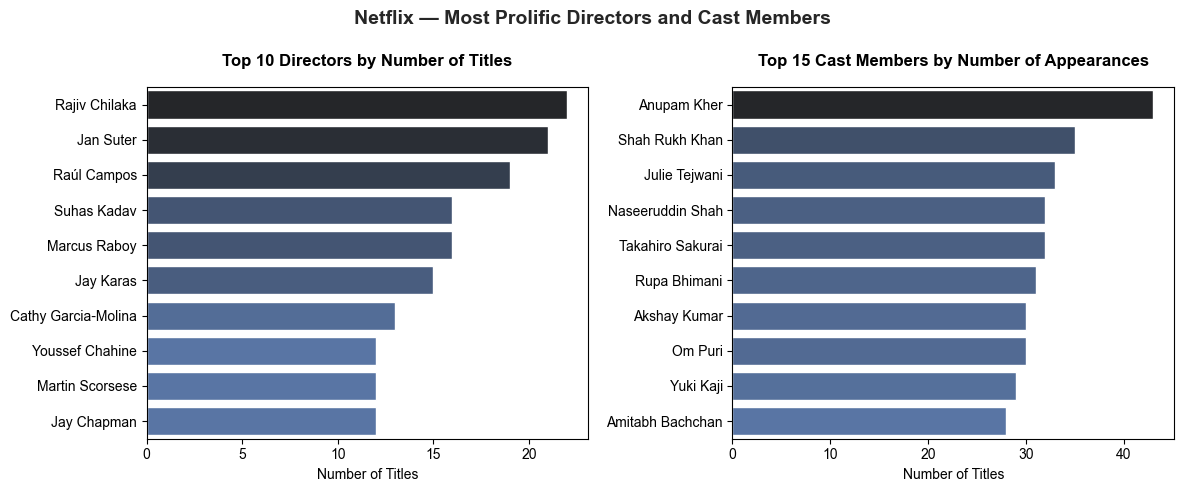

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.set_theme(style='ticks')

# Top 10 Directors
sns.barplot(data=df_top_directors, x='count', y='director', ax=ax[0], hue='count', palette='dark:b_r', legend=False)
ax[0].set_title('Top 10 Directors by Number of Titles', fontweight='bold', pad=15)
ax[0].set_xlabel('Number of Titles')
ax[0].set_ylabel('')

# Top 10 Cast Members
sns.barplot(data=df_top_cast, x='count', y='cast', ax=ax[1], hue='count', palette='dark:b_r', legend=False)
ax[1].set_title('Top 15 Cast Members by Number of Appearances', fontweight='bold', pad=15)
ax[1].set_xlabel('Number of Titles')
ax[1].set_ylabel('')

plt.suptitle('Netflix — Most Prolific Directors and Cast Members', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()